Requerimientos:

- AUTH_TOKEN de [Ngrok](https://ngrok.com/)

### Instalar Librerías de FastAPI y Uvicorn

In [ ]:
# %%capture
!pip -q install --upgrade fastapi uvicorn nest_asyncio python-multipart pyngrok requests

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
!pip -q install --upgrade requests==2.32.4

In [ ]:
import IPython

# Para que los paquetes instalados hagan efecto sobre el entorno, lo reiniciaremos
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

<div class="alert alert-block alert-warning">
<b>⚠️ El kernel se reiniciará. El reinicio puede tomar un mínuto o más. Una vez reiniciado, ejecutar la siguiente celda. ⚠️</b>
</div>

In [ ]:
from google.colab import userdata

## Configuramos el API Key desde el secreto NGROK_AUTH_TOKEN
NGROK_AUTH_TOKEN=userdata.get('NGROK_AUTH_TOKEN')

## Importación de Librerías y Compatibilidad

In [ ]:
import pickle
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# === 1. Cargar el modelo entrenado ===
with open("models/student_regressor_v3.pkl", "rb") as f:
    model = pickle.load(f)

# === 2. Cargar los datos nuevos ===
df = pd.read_csv("data/exams_v3.csv")

# === 3. Renombrar columnas (por si acaso) ===
df = df.rename(columns={
    'race/ethnicity': 'race_ethnicity',
    'gender': 'gender',
    'parental level of education': 'parental_level_of_education'
})

# === 4. Codificar variables categóricas ===
for c in ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']:
    df[c] = LabelEncoder().fit_transform(df[c].astype(str))

# === 5. Separar features y escalar ===
TARGET = "math_score"
X = df.drop(columns=[TARGET], errors="ignore").values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # ⚠️ Si guardaste el scaler, usa el mismo. Si no, aplica un fit nuevo.

# === 6. Predicciones ===
y_pred = model.predict(X_scaled).ravel()

# === 7. Guardar resultados ===
df["pred_math_score"] = y_pred
df.to_csv("predicciones_v3.csv", index=False)

print("✅ Predicciones generadas y guardadas en 'predicciones_v3.csv'")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
✅ Predicciones generadas y guardadas en 'predicciones_v3.csv'


In [ ]:
import pandas as pd
import pathlib as Path
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Implementación del API

In [ ]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from contextlib import asynccontextmanager
from pathlib import Path
import numpy as np
import pickle
import logging
import joblib
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

MODEL_PATH = Path("models/student_regressor_v3.pkl") # modelo guardado
SCALER_PATH = Path("scaler_v3.pkl") # si guardas el StandardScaler
FEATURE_NAMES = [
"gender",
"race_ethnicity",
"parental_level_of_education",
"lunch",
"test_preparation_course",
"reading_score",
"writing_score"
] # ⚠️ Ajusta al orden exacto de tus columnas de entrenamiento

RISK_THRESHOLD = 60.0

class StudentInput(BaseModel):
  gender: int = Field(..., description="0=F, 1=M (según encoding)")
  race_ethnicity: int = Field(..., description="Categoría codificada")
  parental_level_of_education: int = Field(..., description="Nivel educativo codificado")
  lunch: int = Field(..., description="Tipo de almuerzo codificado")
  test_preparation_course: int = Field(..., description="Curso de preparación codificado")
  reading_score: float
  writing_score: float

class PredictionResponse(BaseModel):
  predicted_score: float
  risk_label: str
  risk_probability: float
  feature_order: list[str]

model = None
scaler = None

def load_model():
  global model, scaler
  if not MODEL_PATH.exists():
    raise FileNotFoundError(f"No se encontró el modelo en {MODEL_PATH}")
  with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)
  if SCALER_PATH.exists():
    with open(SCALER_PATH, "rb") as f:
      scaler = pickle.load(f)
  logging.info("Modelo y scaler cargados correctamente.")




@asynccontextmanager
async def lifespan(app: FastAPI):
  try:
    load_model()
  except Exception as e:
    logging.warning(f"No se pudo cargar el modelo al iniciar: {e}")
  yield
# Aquí podrías liberar recursos si es necesario


app = FastAPI(
title="Student Performance API",
version="1.0.0",
lifespan=lifespan
)

@app.get("/health")
def health():
  return {"status": "ok", "model_loaded": model is not None}


@app.post("/predict", response_model=PredictionResponse)
def predict(payload: StudentInput):
  global model, scaler
  if model is None:
    try:
      load_model()
    except Exception as e:
      raise HTTPException(status_code=500, detail=f"Error cargando modelo: {e}")

  x = np.array([[getattr(payload, f) for f in FEATURE_NAMES]])
  if scaler is not None:
      x = scaler.transform(x)

  try:
    y_hat = float(model.predict(x).ravel()[0])
    risk_prob = float(np.clip(1 - (y_hat / 100), 0, 1))
    risk_label = "High Risk" if y_hat < RISK_THRESHOLD else "Low Risk"

    return PredictionResponse(
        predicted_score=y_hat,
        risk_label=risk_label,
        risk_probability=risk_prob,
        feature_order=FEATURE_NAMES
    )
  except Exception as e:
      raise HTTPException(status_code=500, detail=f"Error durante la predicción: {e}")

## Ejecución del Servicio

In [ ]:
from fastapi import FastAPI

app = FastAPI()

@app.get("/")
def read_root():
    return {"mensaje": "Hola desde tu API en Google Colab 🚀"}

@app.get("/estudiantes")
def get_estudiantes():
    return {"estudiantes": ["Ana", "Luis", "Carlos"]}

In [ ]:
from pyngrok import ngrok
import uvicorn
import nest_asyncio
import threading

# Permite reiniciar el bucle de eventos (importante en Colab)
nest_asyncio.apply()

# Abre un túnel al puerto 8000
public_url = ngrok.connect(8000)
print(f"Tu API está disponible en: {public_url}")

# Función para correr el servidor en un hilo
def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_server)
thread.start()

Tu API está disponible en: NgrokTunnel: "https://complexionless-wersh-khalil.ngrok-free.dev" -> "http://localhost:8000"


Después de la ejecución satisfactoria, utilizamos el NGROK_AUTH_TOKEN para el acceso a un servidor público donde cargamos nuestra API basada en el score de estudiantes.
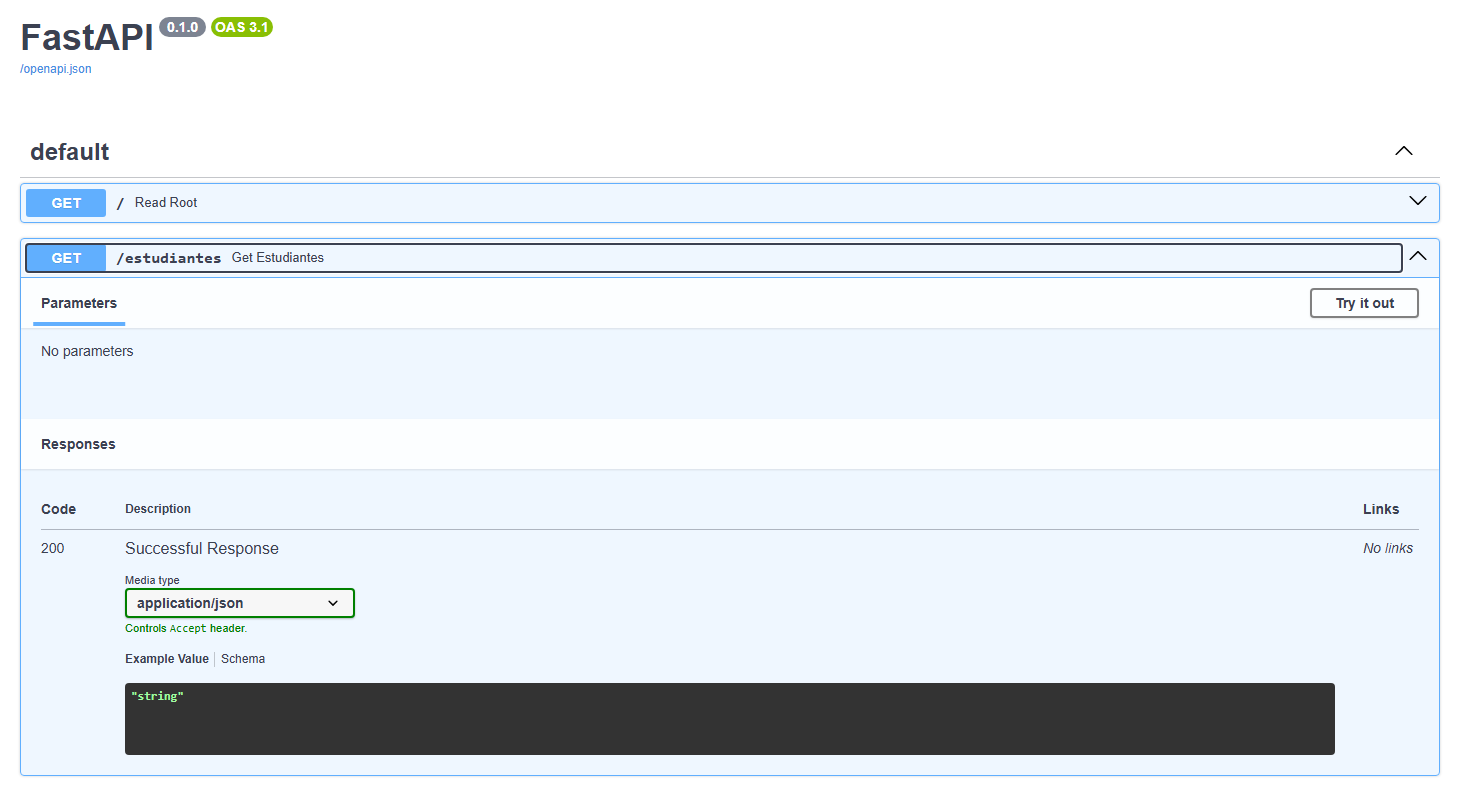